### Pytorch Domain Libraries

Depending on what you are working on, vision, text, audio, recommendation, you will want to look into each of the PyTorch domain liabraries for existing data loading functions and customaizable data loading functions.

1. TorchVision : Anything Image Related
2. TorchText : Anything Text Related
3. TorchAudio : Anything Audio Related
4. TorchRec : Tailored for building, scaling, and deploying large-scale recommendation systems


These also come with existing datasets such as:
1. torchvision.datasets
2. torchtext.datasets
3. torchaudio.datasets
4. torchrec.datasets

BONUS: TorchData contains many helper funtions for loading data and other.

We have used some datasets with PyTorch before.

But how do you get your own custom data into PyTorch?

One of the way to do so is via: custom datasets

### Importing PyTorch and setting device-agnostic codes

In [1]:
import torch
from torch import nn

In [2]:
# Setup device-agnostic code

device = 'cuda' if torch.cuda.is_available() else 'cpu'


## Get Data

Our dataset is a subset of Food101 Dataset.

Food101 starts with 101 different classes of food. And 1000 images per class(750 train images and 250 test images).

Our dataset starts with 3 classes of food and only 10% of the images for each class form original 'Food101' Dataset (i.e: 100 images per class[75 train images and 25 test images]).

Why do this?

When starting out ML projects, it's important to try things on a small scale and then increase the scale when necessary.

The whole point is to speed up how fast you can experiment.

In [3]:
import requests
from pathlib import Path
import zipfile

# Setup path to a data data_path
data_path = Path('data')
image_path = data_path / 'pizza_steak_sushi'

# If the image folder dosen't exist, download it and prepare it...
if image_path.is_dir():
    print(f'"{image_path}" directory already exists. Skipping Download.....')
else:
    print(f'"{image_path}" directory does not exists, creating one...')
    # Create the directory
    image_path.mkdir(parents=True, exist_ok=True)

# Download the pizza, steak and sushi image data
with open(data_path / 'pizza_steak_sushi.zip', 'wb') as f:
    request = requests.get('https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip')
    print('Downloading pizza, steak and sushi image data...')
    f.write(request.content)

# Upzip the downloaded file
with zipfile.ZipFile(data_path / 'pizza_steak_sushi.zip', 'r') as zip_ref:
    print('Unzipping the downloaded data file...')
    zip_ref.extractall(image_path)

"data\pizza_steak_sushi" directory already exists. Skipping Download.....
Unzipping the downloaded data file...


## Data Preparation and Data Exploration

In [4]:
import os

current_dir = os.getcwd()

def walk_through_dir(dir):
    '''
    This functions prints out all the directories and subdirecotires and files in a specified directory
    '''
    for path, directory, files in os.walk(dir):
        print(f'There are {len(directory)} directory and {len(files)} images in path {path}  ')


walk_through_dir(image_path)


There are 2 directory and 0 images in path data\pizza_steak_sushi  
There are 3 directory and 0 images in path data\pizza_steak_sushi\test  
There are 0 directory and 25 images in path data\pizza_steak_sushi\test\pizza  
There are 0 directory and 19 images in path data\pizza_steak_sushi\test\steak  
There are 0 directory and 31 images in path data\pizza_steak_sushi\test\sushi  
There are 3 directory and 0 images in path data\pizza_steak_sushi\train  
There are 0 directory and 78 images in path data\pizza_steak_sushi\train\pizza  
There are 0 directory and 75 images in path data\pizza_steak_sushi\train\steak  
There are 0 directory and 72 images in path data\pizza_steak_sushi\train\sushi  


### Visualizing an Image

Let's write code to:
1. Get all of the image paths
2. Pick a random image path using Python's 'random.choice()'
3. Get the image class name using 'pathlib.Path.parent.stem'
4. Since we are working with images, let's open the images with Python's PIL
5. We will show the image and print the metadata

Image Path: data\pizza_steak_sushi\train\steak\830007.jpg
Image Label: steak
Image Height: 287
Image Width: 512


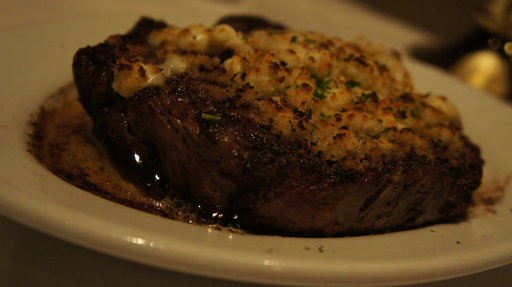

In [5]:
import random
from PIL import Image

# random.seed(42)

# Get all image paths
image_path_list = list(image_path.glob('*/*/*.jpg'))

# Select a random image path
random_image_path = random.choice(image_path_list)

# Get the image class from path name (the image class is the name of the directory where the image is stored)
image_label = random_image_path.parent.stem

image = Image.open(random_image_path)


# Print metadata
print(f'Image Path: {random_image_path}')
print(f'Image Label: {image_label}')
print(f'Image Height: {image.height}')
print(f'Image Width: {image.width}')

image

(np.float64(-0.5), np.float64(511.5), np.float64(286.5), np.float64(-0.5))

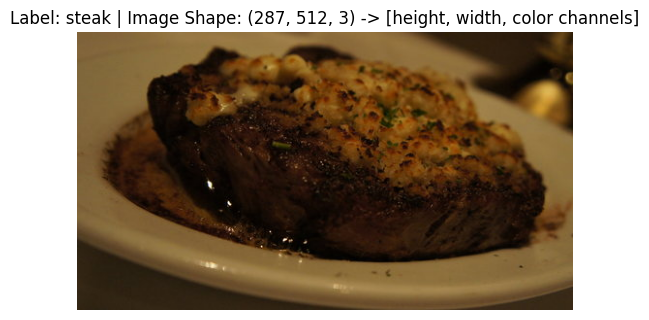

In [6]:
# Try to visualize the image with matplotlib 

import matplotlib.pyplot as plt
import numpy as np

# plt.imshow(image, cmap='gray')
# plt.title(f'Label: {image_label} | {image.size} -> [width, height]')


# Turn the image into array
image_as_array = np.asarray(image) # So it is like array, except it has fewer options, and copy=False. array has copy=True by default.
#The main difference is that array (by default) will make a copy of the object, while asarray will not unless necessary.

# Plot the image wiht matplotlib
plt.imshow(image_as_array)
plt.title(f'Label: {image_label} | Image Shape: {image_as_array.shape} -> [height, width, color channels]')
plt.axis(False)


### Transforming data

Before we can use our image data with PyTorch:
1. Turn your target data into tensors (i.e: numerical representation of our images)
2. Turn it into a `torch.utils.data.Dataset` and subsequently into a `torch.utils.data.DataLoader`, we'll call the these `Dataset` and `DataLoader`

In [7]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

### Transforming data with `torchvision.transforms`

In [8]:
# Write a transform for Image
#  
data_transform = transforms.Compose([
    # Resize the image to 64x64
    transforms.Resize(size=(64, 64)),

    # Flip image horizontally 50% of the time
    transforms.RandomHorizontalFlip(p=0.5),

    # Turn the image into Tensor
    transforms.ToTensor()
    ])

In [9]:
tensor_image = data_transform(image)
tensor_image.shape

torch.Size([3, 64, 64])

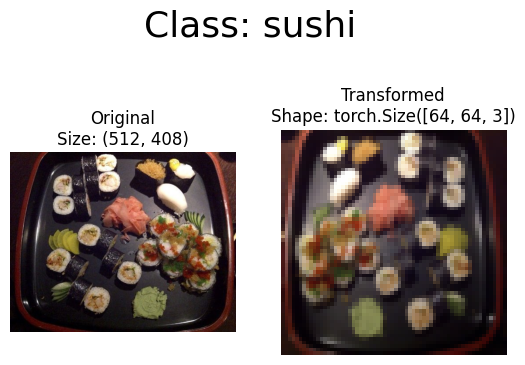

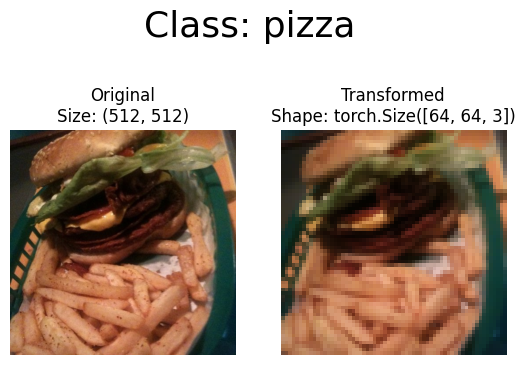

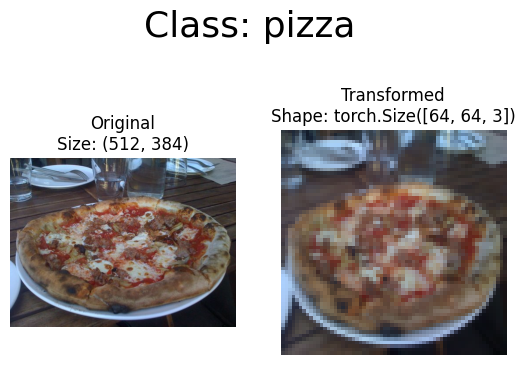

In [10]:
def plot_transformed_image(image_paths: list, transform, n=3, seed=None):
    '''
    Selects random images form a list of 'path of images' and loads/transforms them. Then plots the original vs the transformed version of image 
    '''
    if seed:
        random.seed(seed)

    random_image_paths = random.sample(image_paths, k=n)

    for image_path in random_image_paths:
        with Image.open(image_path) as f:
            fig, ax = plt.subplots(nrows=1, ncols=2)
            ax[0].imshow(f)
            
            ax[0].set_title(f'Original\nSize: {f.size}')
            ax[0].axis(False)

            transformed_image = transform(f).permute(1, 2, 0)
            ax[1].imshow(transformed_image)
            ax[1].set_title(f'Transformed\nShape: {transformed_image.shape}')
            ax[1].axis(False)

            label = image_path.parent.stem
            fig.suptitle(f'Class: {label}', fontsize=26)

plot_transformed_image(image_paths=image_path_list,
                       transform=data_transform,
                       n=3,
                       seed=42)

In [11]:
# Set up train and test path 

train_dir = image_path / 'train'
test_dir = image_path / 'test'

train_dir, test_dir

(WindowsPath('data/pizza_steak_sushi/train'),
 WindowsPath('data/pizza_steak_sushi/test'))

## Loading Image Data using `ImageFolder`

We can load image classification data using `torchvision.datasets.ImageFolder`

In [12]:
# Use ImageFolder to create datasets

train_data = datasets.ImageFolder(root=train_dir,
                                  transform=data_transform, # a transform for the data
                                  target_transform=None) # a transform for the target/label


test_data = datasets.ImageFolder(root=test_dir,
                                 transform=data_transform,
                                 target_transform=None)

train_data, test_data

(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data\pizza_steak_sushi\train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data\pizza_steak_sushi\test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ))

In [13]:
# Index on the train_data Dataset to get a single image and label 

image, label = train_data[0]

print(f'Image tensor:\n{image}')
print(f'Image shape: {image.shape}')
print(f'Image datatype: {image.dtype}')
print(f'Image label: {label}')
print(f'Lable datatype: {type(label)}')

Image tensor:
tensor([[[0.1137, 0.1020, 0.0980,  ..., 0.1255, 0.1216, 0.1176],
         [0.1059, 0.0980, 0.0980,  ..., 0.1294, 0.1294, 0.1294],
         [0.1020, 0.0980, 0.0941,  ..., 0.1333, 0.1333, 0.1333],
         ...,
         [0.1098, 0.1098, 0.1255,  ..., 0.1686, 0.1647, 0.1686],
         [0.0902, 0.0941, 0.1098,  ..., 0.1686, 0.1647, 0.1686],
         [0.0863, 0.0863, 0.0980,  ..., 0.1686, 0.1647, 0.1647]],

        [[0.0745, 0.0706, 0.0745,  ..., 0.0588, 0.0588, 0.0588],
         [0.0745, 0.0706, 0.0745,  ..., 0.0627, 0.0627, 0.0627],
         [0.0706, 0.0745, 0.0745,  ..., 0.0706, 0.0706, 0.0706],
         ...,
         [0.1255, 0.1333, 0.1373,  ..., 0.2510, 0.2392, 0.2392],
         [0.1098, 0.1176, 0.1255,  ..., 0.2510, 0.2392, 0.2314],
         [0.1020, 0.1059, 0.1137,  ..., 0.2431, 0.2353, 0.2275]],

        [[0.0941, 0.0902, 0.0902,  ..., 0.0157, 0.0196, 0.0196],
         [0.0902, 0.0863, 0.0902,  ..., 0.0196, 0.0157, 0.0196],
         [0.0902, 0.0902, 0.0902,  ..., 0.01

Text(0.5, 1.0, 'pizza')

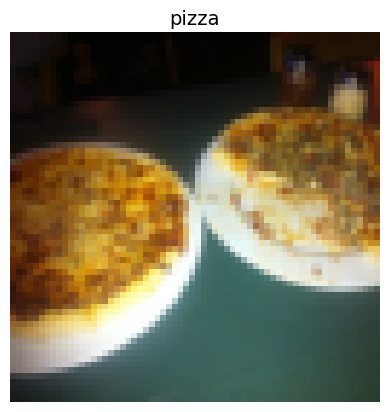

In [14]:
plt.imshow(image.permute(1, 2, 0))
# by permute image goes form [color channels, height, width] -> [height, width, color channels]

plt.axis(False)
plt.title(train_data.classes[label], fontsize=14)

## Turn loaded images into `Dataloader`

A `Dataloader` is going to help us convert our `Datasets` into iterables and we can customize the `BATCH_SIZE` so our model can see one `BATCH_SIZE` images at a time.

In [15]:
# Turn train and test datasets into Dataloader

BATCH_SIZE = 32

train_dataloader = DataLoader(dataset=train_data,
                              batch_size=BATCH_SIZE,
                              shuffle=True)

test_dataloader = DataLoader(dataset=test_data,
                             batch_size=BATCH_SIZE,
                             shuffle=False)

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x236227d2ba0>,
 <torch.utils.data.dataloader.DataLoader at 0x2363348e710>)

## Loading Image Data with a Custom `Dataset`

1. Want to be able to load images from file
2. Want to be able to get class names from the Dataset
3. Want to be able to get classes as dictionary from the Dataset

Pros:
* Can create a `Dataset` out of almost anything
* Not limited to PyTorch pre-built `Dataset` funtions

Cons:
* Even though you could create `Dataset` out of almost anything, it dosen't mean it will work...
* Using a custom `Dataset` often results in us writing more code, which could be prone to errors or performance issues

All custom datasets in PyTorch, often subclass - `torch.utils.data.Dataset`

In [16]:
import os
import pathlib
import torch

from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
from typing import Tuple, Dict, List

## Creating a helper funtion to get class names

We want the function to:
1. Get the class names using `os.scandir()` to traverse a target directory (ideally the directory is in standard image classification format).
2. Raise an error if the class names aren't found (if this happens, there might be something wrong with the directory structure)
3. Turn the class names into a dict and a list and return them.

In [17]:
# Setup path for target directory
target_directory = train_dir
target_directory

WindowsPath('data/pizza_steak_sushi/train')

In [18]:
def find_classes(directory: str) -> Tuple[List[str], Dict[str, int]]:
    ''' Finds the class folder names in a target directory. '''

    # 1. Get the class names by scanning the target director
    classes = sorted(entry.name for entry in list(os.scandir(directory)) if entry.is_dir())

    # 2. Raise an error if class names could not be found
    if not classes:
        raise FileNotFoundError(f"Couldn't find any classes in {directory}...")
    
    # 3. Create a dictionary of index labels (computers prefer numbers rather than strings as labels)
    class_to_idx = {class_name: index for index, class_name in enumerate(classes)}
    # creates a dictionary with {class_name:index , class_name:index, .....},  since the enumerate(classes) gives a tuple with each class names and corresponding index 

    return classes, class_to_idx

In [19]:
find_classes(directory=target_directory)

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

### Create a custom `Dataset` to replicate `ImageFolder`

To create our own custom dataset, we want to:

1. Subclass `torch.utils.data.Dataset`
2. Init our subclass with a target directory (the directory we'd like to get data from) as well as a transform if we'd like to transform our data 
3. Create several attributes:
    * paths - paths of images
    * transform - the transform we'd like to use
    * classes - a list of the target classes
    * class_to_idx - a dict of the target classes mapped to integer labels
4. Create a funtion to `load_images()`, this funtion will open an image
5. Overwrite the `__len__()` method to return the length of our dataset  
6. Overwrite the `__getitem__()` method to return a given sample when passed an index

In [20]:
# Write a custom dataset class

# 1. Subclass torch.utils.data.Dataset
class ImageFolderCustom(Dataset):

    # 2. Initialize our custom dataset 
    def __init__(self, targ_dir:str, transform=None):
        # super().__init__()

        # 3. Create class attributes

        self.paths = list(pathlib.Path(targ_dir).glob('*/*.jpg'))

        self.transform = transform

        self.classes, self.class_to_idx = find_classes(directory=targ_dir)

    # Create a funtion to load images
    def load_image(self, index: int) -> Image.Image:
        "Opens an image via a path and returns it"
        image_path = self.paths[index]
        return Image.open(image_path)
    
    # Overwrite __len__()
    def __len__(self) -> int:
        'Returns the total number of samples'
        return len(self.paths)

    # Overwrite __getitem__() method to return a particular sample
    def __getitem__(self, index: int) -> Tuple[torch.Tensor, int]:
        "Return one sample of data, data and label (X, y)"

        image =  self.load_image(index)
        class_name = self.paths[index].parent.stem # expects path in format: data_folder/class_name/image.jpg
        # label = self.classes.index(class_name)
        label = self.class_to_idx[class_name]
        # label = self.classes.index(self.paths[index].parent.stem)
        
        # Transform if necessary
        if self.transform:
            return self.transform(image), label # return data, label (X, y)
        else:
            return image, label # return untransformed data and label
        
            

In [21]:
from torchvision import transforms

# Create a transform
train_transforms = transforms.Compose([
    transforms.Resize(size=(64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

test_transforms = transforms.Compose([
    transforms.Resize(size=(64, 64)),
    transforms.ToTensor()
])

In [22]:
# Test out ImageFolderCustom
train_data_custom = ImageFolderCustom(targ_dir=train_dir, transform=train_transforms)

test_data_custom = ImageFolderCustom(targ_dir=test_dir, transform=test_transforms)

In [23]:
# Check for equality between original ImageFolder Dataset and ImageFolderCustom Dataset

print(train_data_custom.classes==train_data.classes)
print(test_data_custom.classes==test_data.classes)


True
True


### Create a funtion to display random images

1. Take in a `Dataset` and a number of other parameters such as class names and how many images to visualize.
2. To prevent the display getting out of hand, let's cap the number of images to see at 10.
3. Set the random seed for reproducibility.
4. Get a list of random sample indexes from the target dataset.
5. Setup a matplotlib plot.
6. Loop through the random sample indexes and plot them with matplotlib.
7. Make sure the dimensions of our images lineup with matplotlib (HWC). 

In [24]:
# Create a function to take in a dataset
def display_random_images(dataset: torch.utils.data.Dataset,
                          classes: List[str] = None,
                          n: int = 10,
                          display_shape: bool = True,
                          seed: int = None):
    
    # Adjust display if n is too high
    if n > 10:
        n = 10
        display_shape = False
        print(f'For display purpose, n should not be larger than 10. Setting the n to 10 and removing shape display')
    
    # Set the seed
    if seed:
        random.seed(seed)

    # Get random sample indexes
    random_samples_idx = random.sample(range(len(dataset)), k=n)

    # Setup plot
    plt.figure(figsize=(16, 8))

    # Loop through random indexes and plot them with matplotlib
    for index, value in enumerate(random_samples_idx):
        image, label = dataset[value]

        # Adjust tensor dimension for plotting
        image_adjust = image.permute(1, 2, 0) # [color channels, height, width] -> [height, width, color channels]

        # Plot adjusted samples
        plt.subplot(1, n, index + 1)
        plt.imshow(image_adjust)
        plt.axis(False)

        # if display_shape:
        #     plt.title(f'Label: {classes[label]} | Shape: {image.shape}', size=8)
        # else:
        #     plt.title(f'Label: {classes(label)}', size=8)
        
        if classes:
            title = f'Class: {classes[label]}'
            if display_shape:
                title = title + f'\nShape: {image_adjust.shape}'

        plt.title(title, size=8)

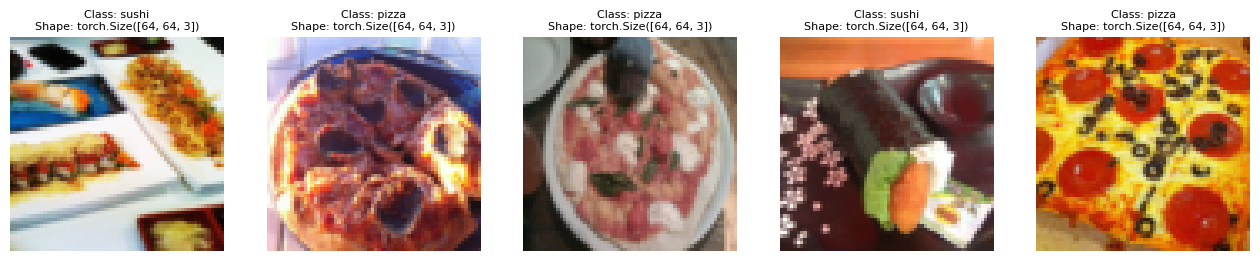

In [25]:
display_random_images(dataset=train_data_custom,
                      classes=train_data_custom.classes,
                      n=5,
                      display_shape=True,
                      seed=42)

In [26]:
# Convert our custom loaded images into dataloader

from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_dataloader_custom = DataLoader(dataset=train_data_custom,
                                     batch_size=BATCH_SIZE,
                                     shuffle=True)

test_dataloader_custom = DataLoader(dataset=test_data_custom,
                                    batch_size=BATCH_SIZE)

train_dataloader_custom, test_dataloader_custom

(<torch.utils.data.dataloader.DataLoader at 0x23633649e50>,
 <torch.utils.data.dataloader.DataLoader at 0x236228c2060>)

In [27]:
# get image and label form custom dataloader

image_custom , label_custom = next(iter(train_dataloader_custom))

image_custom.shape, label_custom.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

## Other form of transforms (data augmentation)

Data augmentation is the process of artificailly adding diversity to your training data by making slight changes.

In cases of image data, The changes can be geometric like flipping, rotating and cropping or Color space transformation like changing saturation adjustment, contrast adjustment and Color Jittering. We can also augment the data by introducing noise to the data.

This results in a model that's more generalizable to unseen data.

In [28]:
# Let's look at trivailaugment

from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize(size=(224, 224)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize(size=(224, 224)),
    transforms.ToTensor()
])

In [29]:
# Get all the image paths
image_path_list = list(image_path.glob('*/*/*.jpg'))

In [30]:
image_path_list[:10]

[WindowsPath('data/pizza_steak_sushi/test/pizza/1152100.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/1503858.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/1687143.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/1925494.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/194643.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/195160.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/2003290.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/2019408.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/2111981.jpg'),
 WindowsPath('data/pizza_steak_sushi/test/pizza/2124579.jpg')]

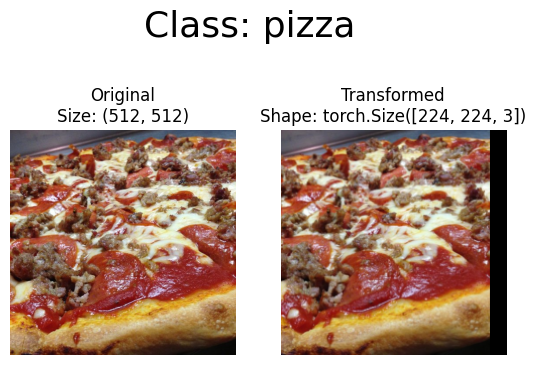

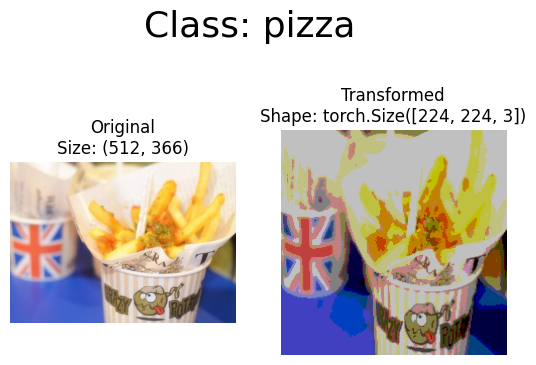

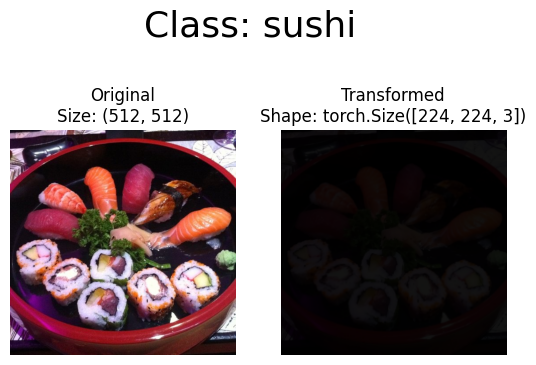

In [31]:
plot_transformed_image(image_paths=image_path_list,
                       transform=train_transform,
                       n=3,
                       seed=None)

## Model 0: TinyVGG without data augmentation

Replicating the TinyVGG Architecture from CNN Explainer website: https://poloclub.github.io/cnn-explainer/

### Creating transforms and loading data for model 0

In [32]:
# Create simple transforms

simple_transform = transforms.Compose([
    transforms.Resize(size=(64, 64)),
    transforms.ToTensor()
])

In [33]:
from torchvision.datasets import ImageFolder
from pathlib import Path

train_directory = Path('data/pizza_steak_sushi/train')
test_directory = Path('data/pizza_steak_sushi/test')

train_data_simple = ImageFolder(root=train_directory,
                                transform=simple_transform)
test_data_simple = ImageFolder(root=test_directory,
                               transform=simple_transform)

In [34]:
# Turn the datasets into Dataloader

from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_dataloader_simple = DataLoader(dataset=train_data_simple,
                                     batch_size=BATCH_SIZE,
                                     shuffle=True)

test_dataloader_simple = DataLoader(dataset=test_data_simple,
                                    batch_size=BATCH_SIZE)

### Create TinyVGG model class

In [35]:
class TinyVGG(nn.Module):
    '''
    Model architecture replicating TinyVGG form CNN Explainer: https://poloclub.github.io/cnn-explainer/ 
    '''
    def __init__(self, input_shape, hidden_units, output_shape):
        super().__init__()

        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),

            nn.ReLU(),

            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),

            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2,
                         stride=2), # default stride value is same as kernel size
        )

        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),

            nn.ReLU(),

            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),

            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2,
                         stride=2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*16*16, out_features=output_shape)
        )
    
    def forward(self, x):
        x = self.conv_block_1(x)
        x = self.conv_block_2(x)
        x = self.classifier(x)
        return x
    
        # return self.classifier(self.conv_block_2(self.conv_block_1)) # benefits form operator fusion

In [36]:
torch.manual_seed(42)

model_0 = TinyVGG(input_shape=3, hidden_units=10, output_shape=len(train_data.classes)).to(device)


### Using `torchinfo` to get an idea of the shapes going through our model

In [37]:
from torchinfo import summary


summary(model_0, input_size=(BATCH_SIZE, 3, 64, 64))

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [32, 3]                   --
├─Sequential: 1-1                        [32, 10, 32, 32]          --
│    └─Conv2d: 2-1                       [32, 10, 64, 64]          280
│    └─ReLU: 2-2                         [32, 10, 64, 64]          --
│    └─Conv2d: 2-3                       [32, 10, 64, 64]          910
│    └─ReLU: 2-4                         [32, 10, 64, 64]          --
│    └─MaxPool2d: 2-5                    [32, 10, 32, 32]          --
├─Sequential: 1-2                        [32, 10, 16, 16]          --
│    └─Conv2d: 2-6                       [32, 10, 32, 32]          910
│    └─ReLU: 2-7                         [32, 10, 32, 32]          --
│    └─Conv2d: 2-8                       [32, 10, 32, 32]          910
│    └─ReLU: 2-9                         [32, 10, 32, 32]          --
│    └─MaxPool2d: 2-10                   [32, 10, 16, 16]          --
├─Sequentia

### Create train and test loop funtions

* `train_step()` - takes in a model and dataloader and trains the model on the dataloader 
* `test_step()` - takes in a model and dataloader and evaluates the model on the dataloader

In [38]:
# Create train_step()
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               device = device):
    
    model.train()

    train_loss, train_acc = 0, 0
    
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        y_logits = model(X)
        y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)

        loss = loss_fn(y_logits, y)
        train_loss += loss.item() # '.item()' so we get the pure value only and not the gradient info, device the value is on, etc
        # if we dont do '.item()' we get the follwing type of value [tensor(1.1120, device='cuda:0', grad_fn=<DivBackward0>)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Calculate accuracy metric
        train_acc += (y_pred==y).sum().item()/len(y_pred)

    train_loss /= len(dataloader)
    train_acc /= len(dataloader)

    return train_loss, train_acc

In [39]:
# Create a test step
def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              device = device):
    
    model.eval()

    test_loss, test_acc = 0, 0

    with torch.inference_mode():
        for batch, (X, y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device)
            y_logits = model(X)
            y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)

            test_loss += loss_fn(y_logits, y).item()

            test_acc += (y_pred==y).sum().item()/len(y_pred)

        test_loss /= len(dataloader)
        test_acc /= len(dataloader)
        
        return test_loss, test_acc

### Creating a train() funtion to combine `train_step()` and `test_step()`

In [40]:
from tqdm.auto import tqdm

def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 10,
          device = device):
    
    # Create empty results dictionary
    results = {'train_loss' : [],
               'train_acc' : [],
               'test_loss' : [],
               'test_acc' : []}

    for epoch in tqdm(range(epochs)):
        train_loss, train_acc =  train_step(model=model,
                                            dataloader=train_dataloader,
                                            loss_fn=loss_fn,
                                            optimizer=optimizer,
                                            device=device)
    
        test_loss, test_acc =  test_step(model=model,
                                         dataloader=test_dataloader,
                                         loss_fn=loss_fn,
                                         device=device)
        
        # Print out what's happening
        print(f'Epoch: {epoch} | Train Loss: {train_loss:.4f} | Train Accuracy: {train_acc:.4f} | Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}')

        # Update result dictionary
        results['train_loss'].append(train_loss)
        results['train_acc'].append(train_acc)
        results['test_loss'].append(test_loss)
        results['test_acc'].append(test_acc)

    return results

c:\Users\ASUS\Desktop\Programming Projects\Food_Classification_CNN\myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Train and evaluate model 0

In [41]:
NUM_EPOCHS = 10

model_0 = TinyVGG(input_shape=3,
                  hidden_units=10,
                  output_shape=len(train_data.classes)).to(device)

# Setup Loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(),
                             lr=0.001)

# Start the timer
from timeit import default_timer as timer

start_time = timer()

# Train model_0
model_0_results = train(model=model_0,
                        train_dataloader=train_dataloader_simple,
                        test_dataloader=test_dataloader_simple,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=NUM_EPOCHS)

# End the timer and print the train time
end_time = timer()
print(f'Total Training Time: {end_time-start_time:.3f} sec')


 10%|█         | 1/10 [00:05<00:50,  5.64s/it]

Epoch: 0 | Train Loss: 1.1060 | Train Accuracy: 0.2734 | Test Loss: 1.0972 | Test Accuracy: 0.2604


 20%|██        | 2/10 [00:07<00:26,  3.36s/it]

Epoch: 1 | Train Loss: 1.0996 | Train Accuracy: 0.3203 | Test Loss: 1.1005 | Test Accuracy: 0.1979


 30%|███       | 3/10 [00:09<00:18,  2.64s/it]

...

Epoch: 7 | Train Loss: 0.9676 | Train Accuracy: 0.5898 | Test Loss: 1.0652 | Test Accuracy: 0.4129


 90%|█████████ | 9/10 [00:19<00:01,  1.83s/it]

Epoch: 8 | Train Loss: 0.9465 | Train Accuracy: 0.4727 | Test Loss: 1.0095 | Test Accuracy: 0.4119


100%|██████████| 10/10 [00:21<00:00,  2.15s/it]

Epoch: 9 | Train Loss: 0.9350 | Train Accuracy: 0.6094 | Test Loss: 1.1231 | Test Accuracy: 0.3314
Total Training Time: 21.506 sec


In [42]:
model_0_results

{'train_loss': [1.1059604436159134,
  1.0995976328849792,
  1.094529151916504,
  1.086701825261116,
  1.0211266428232193,
  1.143227867782116,
  0.9489919319748878,
  0.9676269516348839,
  0.9464960470795631,
  0.9349828884005547],
 'train_acc': [0.2734375,
  0.3203125,
  0.40625,
  0.30078125,
  0.5078125,
  0.42578125,
  0.546875,
  0.58984375,
  0.47265625,
  0.609375],
 'test_loss': [1.0972212155659993,
  1.100450913111369,
  1.0837885936101277,
  1.0499326785405476,
  0.9861605366071066,
  1.0950393478075664,
  1.200932542483012,
  1.065168301264445,
  1.0094928344090779,
  1.1230713327725728],
 'test_acc': [0.2604166666666667,
  0.19791666666666666,
  0.46022727272727276,
  0.38257575757575757,
  0.5634469696969697,
  0.3731060606060606,
  0.3229166666666667,
  0.4128787878787879,
  0.4119318181818182,
  0.331439393939394]}

### Plot the loss curves of model_0

A **loss curve** is a way of tracking your model's progress over time.

In [43]:
# Get the model_0 results key
model_0_results.keys()

dict_keys(['train_loss', 'train_acc', 'test_loss', 'test_acc'])

In [44]:
def plot_loss_curves(results: Dict[str, List[float]]):
    '''Plots training curves of a results dictionary'''

    # Get the loss values of the result dicitionary(training and test)

    loss = results['train_loss']
    test_loss = results['test_loss']

    # Get the accuracy values of the results dicitonary(training and test)
    accuracy = results['train_acc']
    test_accuracy = results['test_acc']

    epoch_count = range(len(results['train_loss']))

    # Setup a plot
    plt.figure(figsize=(15, 7))

    # Plot the loss
    plt.subplot(1, 2, 1)
    plt.plot(epoch_count, loss, label='Train Loss')
    plt.plot(epoch_count, test_loss, label='Test Loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    
    # Plot the accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epoch_count, accuracy, label='Train Accuracy')
    plt.plot(epoch_count, test_accuracy, label='Test Accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

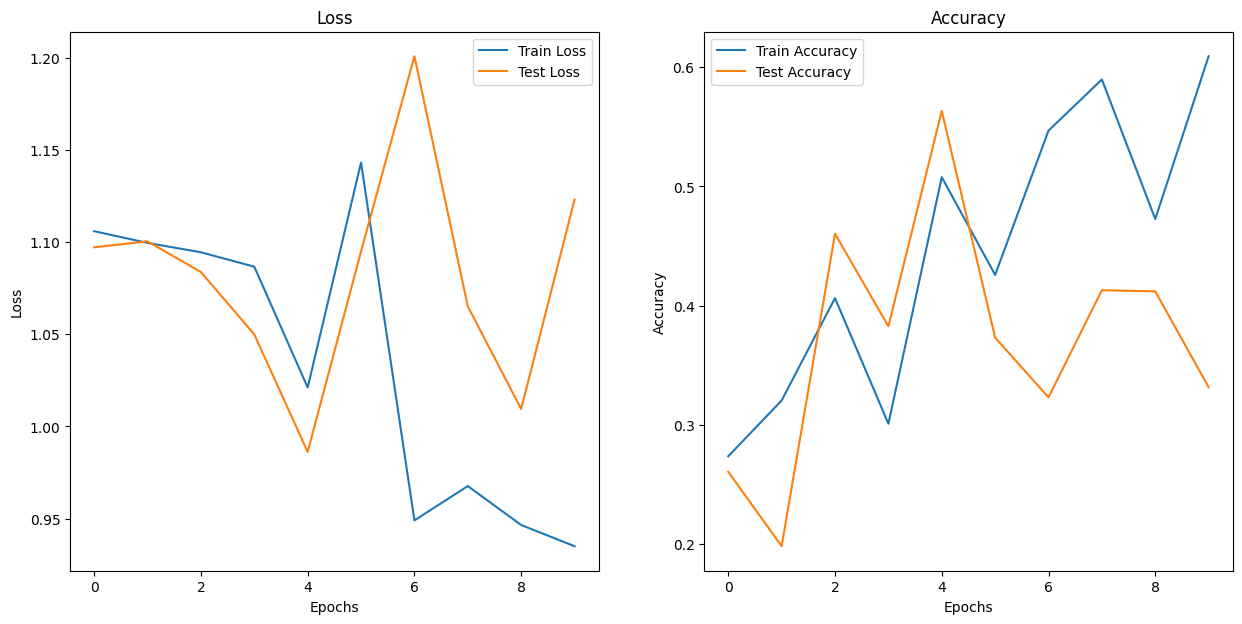

In [45]:
plot_loss_curves(model_0_results)

### What should an ideal loss curve look like?

A loss curve is one of the most helpful way to troubleshoot a model to make it perform better.

![Underfitting vs Overfitting vs Just Right](./UnderfittingvsOverfittingvsJustright.jpg)

# Dealing with Overfitting

|Method to prevent overfitting  | What is it? |
|-------------------------------|-------------|
|Get more data|Having more data gives the model more opportunities to learn patterns, patterns which may be more generalizable to new examples.|
|Simplify your model| If the current model is already overfitting the training data, it may be too complicated of a model. This means it's learning the patterns of the data too well and isn't able to generalize well to unseen data. One way to simplify a model is to reduce the number of layers it uses or to reduce the number of hidden units in each layer.|
|Use data augmentation | Data augmentation manipulates the training data in a way so that's harder for the model to learn as it artificially adds more variety to the data. If a model is able to learn patterns in augmented data, the model may be able to generalize better to unseen data.
|Use transfer learning|Transfer learning involves leveraging the patterns (also called pretrained weights) one model has learned to use as the foundation for your own task. In our case, we could use one computer vision model pretrained on a large variety of images and then tweak it slightly to be more specialized for food images.|
|Use dropout layers | Dropout layers randomly remove connections between hidden layers in neural networks, effectively simplifying a model but also making the remaining connections better. See `torch.nn.Dropout()` for more.|
|Use learning rate decay| The idea here is to slowly decrease the learning rate as a model trains. This is akin to reaching for a coin at the back of a couch. The closer you get, the smaller your steps. The same with the learning rate, the closer you get to convergence, the smaller you'll want your weight updates to be. See `torch.optim.lr_scheduler` for more.|
|Use early stopping | Early stopping stops model training before it begins to overfit. As in, say the model's loss has stopped decreasing for the past 10 epochs (this number is arbitrary), you may want to stop the model training here and go with the model weights that had the lowest loss (10 epochs prior).|

# Dealing with Underfitting

|Method to prevent underfitting| What is it?|
|---|-----|
|Add more layers/units to your model | If your model is underfitting, it may not have enough capability to learn the required patterns/weights/representations of the data to be predictive. One way to add more predictive power to your model is to increase the number of hidden layers/units within those layers.|
|Tweak the learning rate | Perhaps your model's learning rate is too high to begin with. And it's trying to update its weights each epoch too much, in turn not learning anything. In this case, you might lower the learning rate and see what happens.|
|Use transfer learning |Transfer learning is capable of preventing overfitting and underfitting. It involves using the patterns from a previously working model and adjusting them to your own problem.|
|Train for longer |	Sometimes a model just needs more time to learn representations of data. If you find in your smaller experiments your model isn't learning anything, perhaps leaving it train for a more epochs may result in better performance.|
|Use less regularization | Perhaps your model is underfitting because you're trying to prevent overfitting too much. Holding back on regularization techniques can help your model fit the data better.|

# Model 1:TinyVGG with Data Augmentation

Let's try another modelling experiment. This time using the same model as before but with data augmentation.

In [46]:
# Create training transfrom with Trivial Augment

from torchvision import transforms

train_transform_trivial = transforms.Compose([
    transforms.Resize(size=(64, 64)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor()
])

test_transform_simple = transforms.Compose([
    transforms.Resize(size=(64, 64)),
    transforms.ToTensor()
])

### Create train and test `Dataset's` and `DataLoader's` with data augmentation

In [47]:
# Turn image folders into Datasets

from torchvision.datasets import ImageFolder

train_data_augmented = ImageFolder(root=train_dir,
                                   transform=train_transform_trivial,
                                   target_transform=None)

test_data_simple = ImageFolder(root=test_dir,
                               transform=test_transform_simple,
                               target_transform=None)

In [48]:
# Turn our Datasets into DataLoader's

from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_dataloader_augmented = DataLoader(dataset=train_data_augmented,
                                        batch_size=BATCH_SIZE,
                                        shuffle=True)

test_dataloader_simple = DataLoader(dataset=test_data_simple,
                                    batch_size=BATCH_SIZE,
                                    shuffle=False)

### Construct and train model_1

This time we'll be using the same model architecture expect we've augmented the training data.

In [49]:
# Create model_1 and send it to the target device (GPU)

model_1 = TinyVGG(input_shape=3,
                  hidden_units=10,
                  output_shape=len(train_data_augmented.classes)).to(device)

model_1

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2560, out_features=3, bias=True)
  )
)

Now that we have a model and dataloaders, let's create a loss funtion and an optimizer and call upon `train()` function to train and evaluate our model.

In [50]:
# Set the number of epochs

NUM_EPOCHS = 10

# Setup loss funtion and optimizer
# NOTE: Loss funtion is often/as-well called `criterion` in PyTorch

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_1.parameters(),
                             lr=0.001)

# Start the timer
from timeit import default_timer as timer

start_time = timer()

# Train model_1
model_1_results = train(model=model_1,
                        train_dataloader=train_dataloader_augmented,
                        test_dataloader=test_dataloader_simple,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=NUM_EPOCHS,
                        device=device)

# End the timer and print the total training time
end_time = timer()
print(f'Total training time for model_1: {end_time - start_time:.3f} seconds')

 10%|█         | 1/10 [00:01<00:16,  1.85s/it]

Epoch: 0 | Train Loss: 1.1129 | Train Accuracy: 0.2930 | Test Loss: 1.1048 | Test Accuracy: 0.1979


 20%|██        | 2/10 [00:03<00:14,  1.84s/it]

Epoch: 1 | Train Loss: 1.0910 | Train Accuracy: 0.4375 | Test Loss: 1.0807 | Test Accuracy: 0.5417


 30%|███       | 3/10 [00:05<00:13,  1.87s/it]

...

Epoch: 7 | Train Loss: 1.0800 | Train Accuracy: 0.3789 | Test Loss: 1.0578 | Test Accuracy: 0.4441


 90%|█████████ | 9/10 [00:17<00:01,  1.95s/it]

Epoch: 8 | Train Loss: 1.0362 | Train Accuracy: 0.5547 | Test Loss: 1.0148 | Test Accuracy: 0.4517


100%|██████████| 10/10 [00:19<00:00,  1.94s/it]

Epoch: 9 | Train Loss: 1.0220 | Train Accuracy: 0.4062 | Test Loss: 1.0004 | Test Accuracy: 0.4848
Total training time for model_1: 19.437 seconds


### Plot the loss curves of model 1

A loss curve helps you evaluate your models performance overtime. 

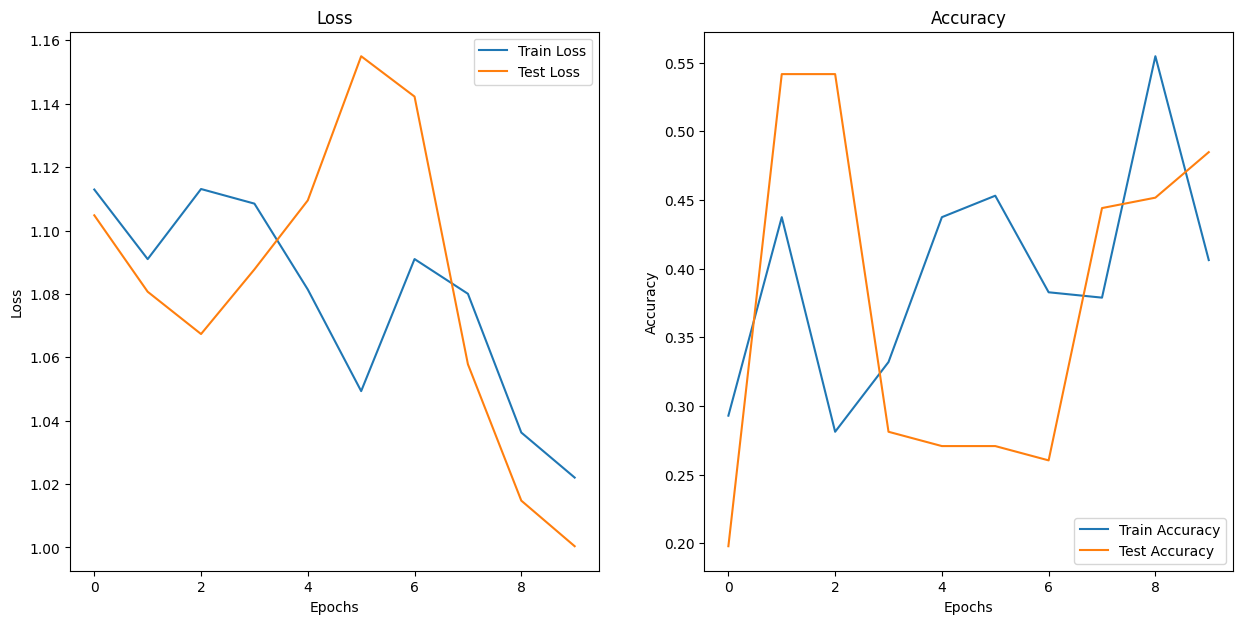

In [51]:
plot_loss_curves(model_1_results)

## Compare model results

After evaluating our model experiments on their own, it's important to compare them to each other.

There's a few different ways to do this:
1. Hard Coding (what we are doing)
2. PyTorch + TensorBoard (`torch.utils.tensorboard`)
3. Weights and Biases - `https://wandb.ai/site/experiment-tracking/`
4. MLflow - `https://mlflow.org/`

In [52]:
import pandas as pd

model_0_df = pd.DataFrame(model_0_results)

model_1_df = pd.DataFrame(model_1_results)

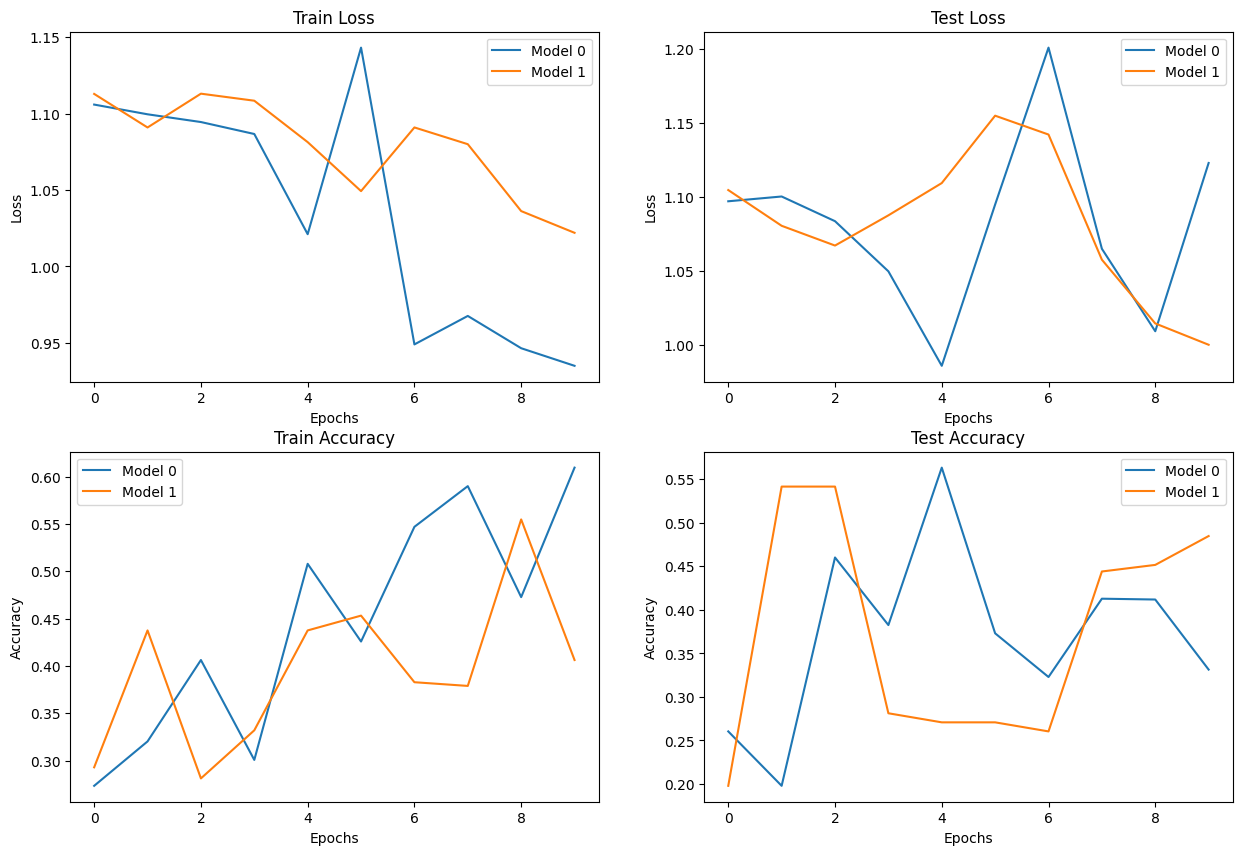

In [53]:
# Setup plot
plt.figure(figsize=(15, 10))

# Get number of epochs
epochs = range(len(model_0_df))

# Plot train loss
plt.subplot(2, 2, 1)
plt.plot(epochs, model_0_df['train_loss'], label='Model 0')
plt.plot(epochs, model_1_df['train_loss'], label='Model 1')
plt.title('Train Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot test loss
plt.subplot(2, 2, 2)
plt.plot(epochs, model_0_df['test_loss'], label='Model 0')
plt.plot(epochs, model_1_df['test_loss'], label='Model 1')
plt.title('Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot train accuracy
plt.subplot(2, 2, 3)
plt.plot(epochs, model_0_df['train_acc'], label='Model 0')
plt.plot(epochs, model_1_df['train_acc'], label='Model 1')
plt.title('Train Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot test accuracy
plt.subplot(2, 2, 4)
plt.plot(epochs, model_0_df['test_acc'], label='Model 0')
plt.plot(epochs, model_1_df['test_acc'], label='Model 1')
plt.title('Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

## Making a Prediction on a custom image

Although we have trained a model on custom data... how do you make a prediction on a sample/image that's not in either training or testing dataset.

In [54]:
# Download custom image
import requests

# Setup custom image path
data_path = Path('data')

custom_image_path = data_path / 'pizza-dad.jpg'

# Download the image if it doesn't already exist

if custom_image_path.is_file():
    print(f'{custom_image_path} file already exists. Skipping Download.....')
else:
    with open(custom_image_path, 'wb') as f:
        # When downloading from GitHub, need to use the 'raw' file link.
        request = requests.get('https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/04-pizza-dad.jpeg')

        print(f'Downloading {custom_image_path}...')

        f.write(request.content)


data\pizza-dad.jpg file already exists. Skipping Download.....


### Loading in a custom image with PyTorch

We have to make sure our custom image is in the same format as the data our model was trained on.

* In tensor form with datatype (torch.float32)
* Of shape 64x64x3
* On the right device (CUDA)

In [55]:
import torchvision

# Read in custom image

custom_image_uint8 = torchvision.io.read_image(path=custom_image_path)
custom_image_uint8.dtype

print(f'Custom image tensor:\n{custom_image_uint8}')
print(f'Custom image tensor shape: {custom_image_uint8.shape}')
print(f'Custom image tensor dtype: {custom_image_uint8.dtype}')
print(f'Custom image tensor device: {custom_image_uint8.device}')

# plt.imshow(custom_image_uint8.permute(1, 2, 0))

Custom image tensor:
tensor([[[154, 173, 181,  ...,  21,  18,  14],
         [146, 165, 181,  ...,  21,  18,  15],
         [124, 146, 172,  ...,  18,  17,  15],
         ...,
         [ 72,  59,  45,  ..., 152, 150, 148],
         [ 64,  55,  41,  ..., 150, 147, 144],
         [ 64,  60,  46,  ..., 149, 146, 143]],

        [[171, 190, 193,  ...,  22,  19,  15],
         [163, 182, 193,  ...,  22,  19,  16],
         [141, 163, 184,  ...,  19,  18,  16],
         ...,
         [ 55,  42,  28,  ..., 107, 104, 103],
         [ 47,  38,  24,  ..., 108, 104, 102],
         [ 47,  43,  29,  ..., 107, 104, 101]],

        [[119, 138, 147,  ...,  17,  14,  10],
         [111, 130, 145,  ...,  17,  14,  11],
         [ 87, 111, 136,  ...,  14,  13,  11],
         ...,
         [ 35,  22,   8,  ...,  52,  52,  48],
         [ 27,  18,   4,  ...,  50,  49,  44],
         [ 27,  23,   9,  ...,  49,  46,  43]]], dtype=torch.uint8)
Custom image tensor shape: torch.Size([3, 4032, 3024])
Custom imag

tensor([[-0.1051, -0.2117, -0.1423]], device='cuda:0',
       grad_fn=<AddmmBackward0>)


Text(0.5, 1.0, 'pizza')

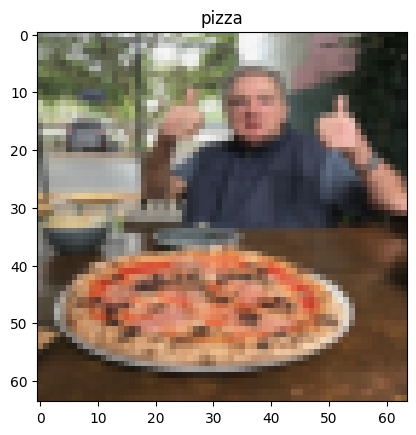

In [56]:
from torchvision import transforms

custom_image_transform = transforms.Compose([
    transforms.Resize(size=(64, 64)),
    transforms.ToTensor()
]) 


from PIL import Image

custom_image = custom_image_path
custom_image = Image.open(custom_image)

custom_image_tensor = custom_image_transform(custom_image)



# Batchify our data
custom_image_tensor_batched = custom_image_tensor.unsqueeze(dim=0)

label_logits = model_1(custom_image_tensor_batched.to(device))
print(label_logits)
label = torch.softmax(label_logits, dim=1).argmax(dim=1)
label

prediction_label = train_data_augmented.classes[label]
prediction_label

plt.imshow(custom_image_tensor.permute(1, 2, 0))
plt.title(train_data_augmented.classes[label])

# Grad-CAM Implementation

In [163]:
def compute_grad(model, image):
    return 2

In [164]:
# Register hooks and attach it to the last conv layer of the model

gradients = []
activations = []

def forward_hook(module, input, output):
    activations.append(output)

def backward_hook(module, grad_input, grad_output):
    gradients.append(grad_output[0])


target_layer = model_1.conv_block_2[4]

forward_handle = target_layer.register_forward_hook(forward_hook)
backward_handle = target_layer.register_full_backward_hook(backward_hook)

In [165]:
# Upon forward pass the activations will be registered / saved as defined in the forward hook

# Get the image for inference and forward pass it thorugh the model to activate hooks

from PIL import Image
from pathlib import Path

image_path = Path('data/pizza-dad.jpg')
# image_path = Path('data/pizza_steak_sushi/train/pizza/138855.jpg')
image = Image.open(image_path)

image_tensor = custom_image_transform(image)

logits = model_1(image_tensor.unsqueeze(dim=0).to(device))

target_class = logits.argmax().item() # gets the index of the highest item form the logits

In [166]:
# The backward hook saves the gradients

model_1.zero_grad()
logits[0, target_class].backward()

In [167]:
print(len(gradients))
print(len(activations))
print(gradients[0].shape)
print(activations[0].shape)

1
1
torch.Size([1, 10, 16, 16])
torch.Size([1, 10, 16, 16])


In [168]:
forward_handle.remove()
backward_handle.remove()

In [169]:
# Now that we have value of all the feature maps form last convolutional layer and the gradients too. Lets compute the `weighted feature map`

import torch.nn.functional as F

grads = gradients[0]
acts = activations[0]

weights = grads.mean(dim=(2, 3), keepdim=True) # gives a^c k(i.e: weight for each of the given feature map)

cam = (weights * acts).sum(dim=1, keepdim=True) # we multiply each of the feature map(acts) by its weight. Then we perform element-wise summation.

cam = F.relu(cam) # clear out negative value of the `weighted feature map`. It's because we are only interested in value that contribute to the model decision and not vlaues that negatively contribute to model decision 

cam = F.interpolate(cam, size=(64, 64), mode='bilinear', align_corners=False)   # interpolate means to estimate an unknown value that falls between two known values. we do this here to increase the dimension of the weighted feature map to the same shape as the input image.

cam = cam.squeeze().cpu().detach().numpy() # squeeze the dim, take the tensor form cuda to cpu, detach the gradient( this will make sure it is no longer connected to computation graph), and convert to numpy

cam = (cam - cam.min()) / (cam.max() - cam.min()) # normalize to [0, 1]

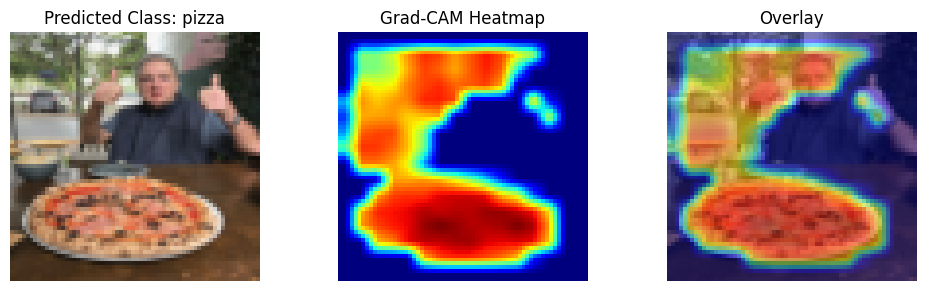

In [170]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3))

axes[0].imshow(image_tensor.permute(1, 2, 0))
# axes[0].set_title('Original Image')
axes[0].set_title(f'Predicted Class: {train_data.classes[target_class]}')
axes[0].axis('off')

axes[1].imshow(cam, cmap='jet')
axes[1].set_title('Grad-CAM Heatmap')
axes[1].axis('off')


axes[2].imshow(image_tensor.permute(1, 2, 0))
axes[2].imshow(cam, cmap='jet', alpha=0.5)
axes[2].axis('off')
axes[2].set_title('Overlay')

plt.tight_layout()
plt.show()

In [ ]:
import cv2


img_8u = (cam * 255).astype(np.uint8)
heatmap = cv2.applyColorMap(img_8u, cv2.COLORMAP_JET)



# image = cv2.imread(image_path)

custom_image_uint8 = torchvision.io.read_image(path=custom_image_path)
custom_image_uint8.dtype

transformed_image = custom_image_transform(custom_image_path)

heatmap = cv2.applyColorMap((cam*255).astype(np.uint8), cv2.COLORMAP_JET)

# overlay = cv2.addWeighted(image, 0.6, heatmap, 0.4, 0)
# heatmap.shape